In [4]:
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import torch
from scipy.ndimage import maximum_filter, uniform_filter

### Intro to pooling layers
* What are pooling layers
    * used to reduce the dimensions of feature maps while retaining the most important information
    * Help make the network computationally efficeint and robust to variations in the input
    * Types Of pooling
        * MaxPooling
        * Average pooling
    * Dimensionality Reduction
        * pooling reduces the spatial dimensions (height and width ) of feature maps resutling in fewer parameters and faster computations
    * Robustness
        * Make the model invariant to small translations or distortions in the input image
### Combining conv and pooling layers
* Pooling Layers typically follow conv layers to downsample thje ffeateurs maps
* This combination helps extract hierarchial features
    * early layers focus on simple features eg edges
    * Deeper layer capture complex patterns eg object
    

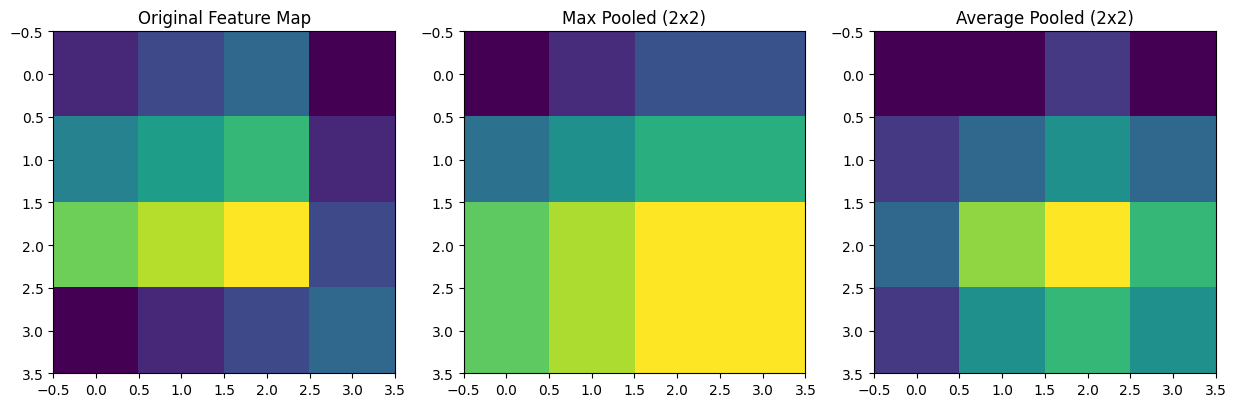

In [6]:
# Create a sample feartuer map
feature_map = np.array([
    [1,2,3,0],
    [4,5,6,1],
    [7,8,9,2],
    [0,1,2,3]
])
# Max Pooling (2x2)
max_pooled = maximum_filter(feature_map, size=2, mode='constant',)
average_pooled = uniform_filter(feature_map, size=2, mode='constant')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(feature_map, cmap='viridis')
axes[0].set_title('Original Feature Map')
axes[1].imshow(max_pooled, cmap='viridis')
axes[1].set_title('Max Pooled (2x2)')
axes[2].imshow(average_pooled, cmap='viridis')
axes[2].set_title('Average Pooled (2x2)')
plt.show()

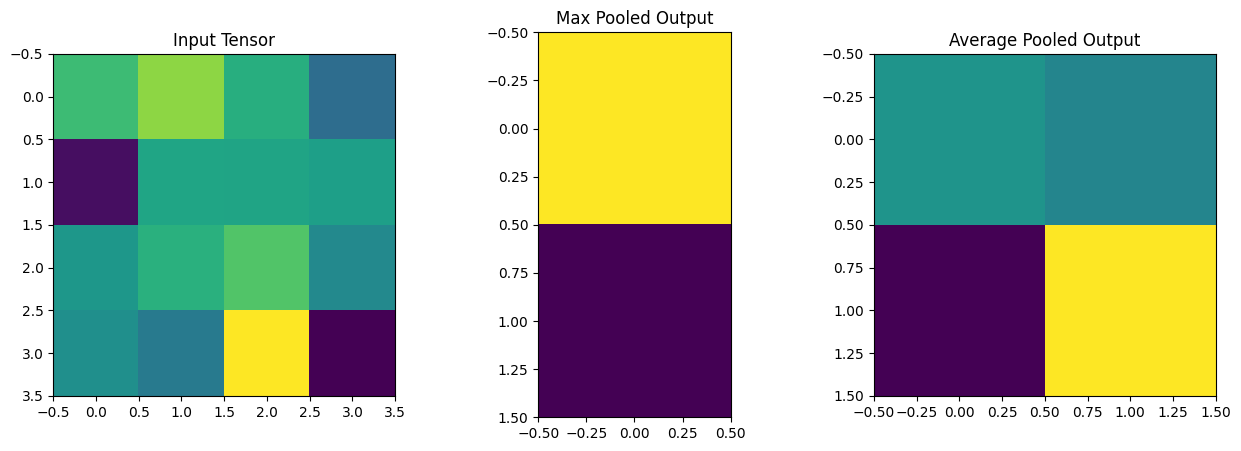

In [9]:
# Apply in tensorflow

# Create a sample input tensor (batch_size, height, width, channels)
input_tensor = tf.random.normal([1, 4, 4, 1], dtype=tf.float32)

# Max Pooling
max_pooled = tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2, padding='valid')
max_pooled_output = max_pooled(input_tensor)

# Average Pooling
average_pooled = tf.keras.layers.AveragePooling2D(pool_size=(2, 2), strides=2, padding='valid')
average_pooled_output = average_pooled(input_tensor)

# Visualize the results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(input_tensor [0, :, :, 0], cmap='viridis')
axes[0].set_title('Input Tensor')
axes[1].imshow(max_pooled_output [0, 0, :, :], cmap='viridis')
axes[1].set_title('Max Pooled Output')
axes[2].imshow(average_pooled_output [0, :, :, 0], cmap='viridis')
axes[2].set_title('Average Pooled Output')
plt.show()

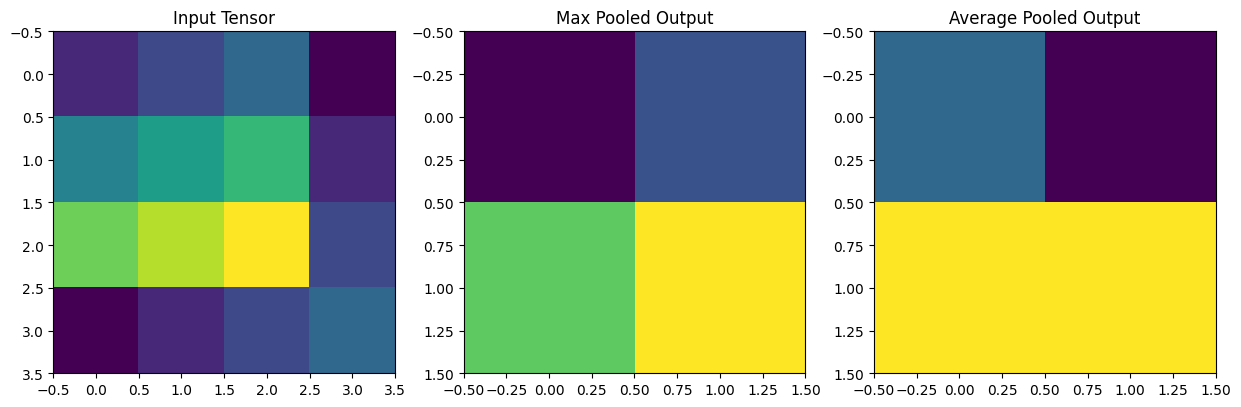

In [10]:
# Apply in PyTorch
input_tensor = torch.tensor(feature_map, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # Batch size of 1, 1 channel, 4x4 image

# Max Pooling
max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
max_pooled_output = max_pool(input_tensor)

# Average Pooling
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)
average_pooled_output = avg_pool(input_tensor)

# Visualize the results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(input_tensor[0,0].detach().numpy(), cmap='viridis')
axes[0].set_title('Input Tensor')
axes[1].imshow(max_pooled_output[0,0].detach().numpy(), cmap='viridis')
axes[1].set_title('Max Pooled Output')
axes[2].imshow(average_pooled_output[0,0].detach().numpy(), cmap='viridis')
axes[2].set_title('Average Pooled Output')
plt.show()

In [ ]:
# tensorflow
model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32,32,3)),
    tf.keras.layers.Conv2D(32,(3,3), activation='relu',),
    tf.keras.layers.MaxPooling2D(pool_size=(2,2)),
    tf.keras.layers.Conv2D(64,(3,3), activation='relu',),
    tf.keras.layers.AveragePooling2D(pool_size=(2,2)),
])

In [ ]:
# pytorch
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN,self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32,kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(32,64, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.AveragePool2d(2,2)
    def forward(self,x):
        x = self.pool2(torch.relu(self.conv2(self.pool1(torch.relu(self.conv1(x))))))
        return x